In [4]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


In [3]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [8]:
# Setting to make numbers easier to read on display
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns on output
pd.set_option('display.max_columns', 999)

In [84]:
df = pd.read_excel("online_retail_II.xlsx", sheet_name=0)

df.head(10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [86]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845018,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [87]:
df.describe(include="O")

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [88]:
df = df.drop_duplicates()

In [89]:
df[df["Description"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.00,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.00,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.00,NaN,United Kingdom
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.00,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.00,NaN,United Kingdom


In [90]:
df[df["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [91]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


In [92]:
df["Invoice"] = df["Invoice"].astype("str")
df[df["Invoice"].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.00,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.00,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.00,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.00,United Kingdom


In [93]:
df["Invoice"].str.replace(r"\d", "", regex=True).unique()

<ArrowStringArray>
['', 'C', 'A']
Length: 3, dtype: str

In [94]:
df[df["Invoice"].str.match(r"^A", na=False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [95]:
df["StockCode"] = df["StockCode"].astype("str")
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

<ArrowStringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',      '47503J ',
           'C3',       'SP1002',    'AMAZONFEE']
Length: 55, dtype: str

In [96]:
df[df["StockCode"].str.contains("^DCGSSGIRL")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80231,496722,DCGSSGIRL,NaN,-1,2010-02-03 14:04:00,0.00,NaN,United Kingdom
241372,512738,DCGSSGIRL,update,100,2010-06-17 14:11:00,0.00,NaN,United Kingdom
244831,513099,DCGSSGIRL,GIRLS PARTY BAG,3,2010-06-21 15:13:00,3.36,NaN,United Kingdom
246184,513200,DCGSSGIRL,GIRLS PARTY BAG,6,2010-06-22 16:28:00,3.36,NaN,United Kingdom
249938,513574,DCGSSGIRL,GIRLS PARTY BAG,1,2010-06-25 15:13:00,3.36,NaN,United Kingdom
251930,513655,DCGSSGIRL,GIRLS PARTY BAG,5,2010-06-28 10:02:00,3.36,NaN,United Kingdom
253997,513907,DCGSSGIRL,GIRLS PARTY BAG,1,2010-06-29 12:08:00,3.36,NaN,United Kingdom
385192,526405,DCGSSGIRL,GIRLS PARTY BAG,6,2010-10-11 13:53:00,3.36,NaN,United Kingdom
425616,530060,DCGSSGIRL,GIRLS PARTY BAG,2,2010-11-01 11:35:00,3.36,NaN,United Kingdom
427107,530140,DCGSSGIRL,GIRLS PARTY BAG,12,2010-11-01 16:45:00,3.36,NaN,United Kingdom


In [97]:

df[df["StockCode"].str.contains("^PADS",na=False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,0.00,16705.00,United Kingdom
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,0.00,13583.00,United Kingdom
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,0.00,17350.00,United Kingdom
79794,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-03 11:58:00,0.00,13408.00,United Kingdom
90798,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-15 10:47:00,0.00,13408.00,United Kingdom
97716,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-21 12:03:00,0.00,15182.00,United Kingdom
101718,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-24 13:46:00,0.00,13765.00,United Kingdom
104480,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-26 13:26:00,0.00,14459.00,United Kingdom
123947,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-03-15 11:00:00,0.00,14857.00,United Kingdom
156809,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-04-12 16:30:00,0.00,12671.00,Germany


In [98]:
cleaned_df = df.copy()


In [99]:
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")

mask = (
    cleaned_df["Invoice"].str.match("^\\d{6}$") == True
)

cleaned_df = cleaned_df[mask]

cleaned_df


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [100]:
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype("str")

mask = (
    (cleaned_df["StockCode"].str.match("^\\d{5}$") == True)
    | (cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
)

cleaned_df = cleaned_df[mask]

cleaned_df


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [101]:
cleaned_df.dropna(subset=["Customer ID"], inplace=True)


In [102]:
len(cleaned_df[cleaned_df["Price"] == 0])


28

In [103]:
cleaned_df = cleaned_df[cleaned_df["Price"] > 0.0]

In [104]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,399552.00,399552,399552.00,399552.00
mean,13.80,2010-07-01 05:02:02.543548,3.00,15366.77
min,1.00,2009-12-01 07:45:00,0.03,12346.00
25%,2.00,2010-03-26 13:42:00,1.25,13995.00
50%,5.00,2010-07-09 10:26:00,1.95,15311.00
75%,12.00,2010-10-14 14:08:00,3.75,16809.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.80,NaN,4.31,1678.20


In [105]:
cleaned_df["Price"].min()

np.float64(0.03)

In [106]:
retention_ratio = len(cleaned_df) / len(df)
drop_pct = (1 - retention_ratio) * 100

retention_ratio, f"Dropped about {drop_pct:.0f}% of records during cleaning"

(0.7704494442687564, 'Dropped about 23% of records during cleaning')

In [107]:
cleaned_df["SalesLineTotal"] = (cleaned_df["Quantity"] * cleaned_df["Price"]).round(2)

In [108]:
aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
    .agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,169.36,2,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,221.16,1,2010-09-27 14:59:00
3,12349.00,2221.14,2,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00


In [109]:
max_invoice_date = aggregated_df["LastInvoiceDate"].max()

aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


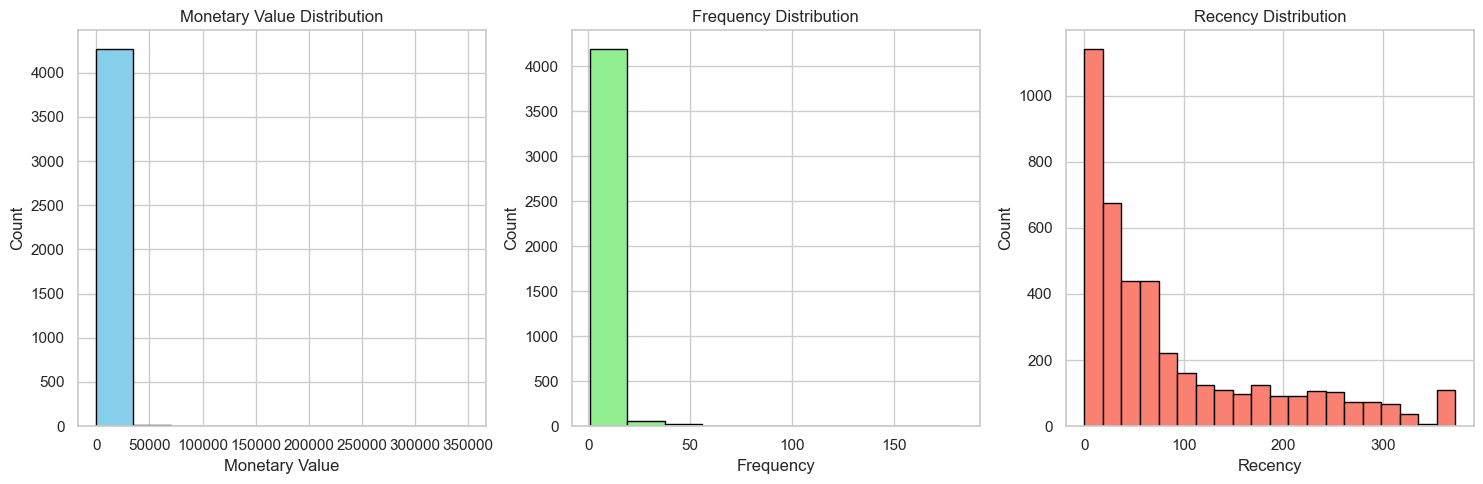

In [110]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

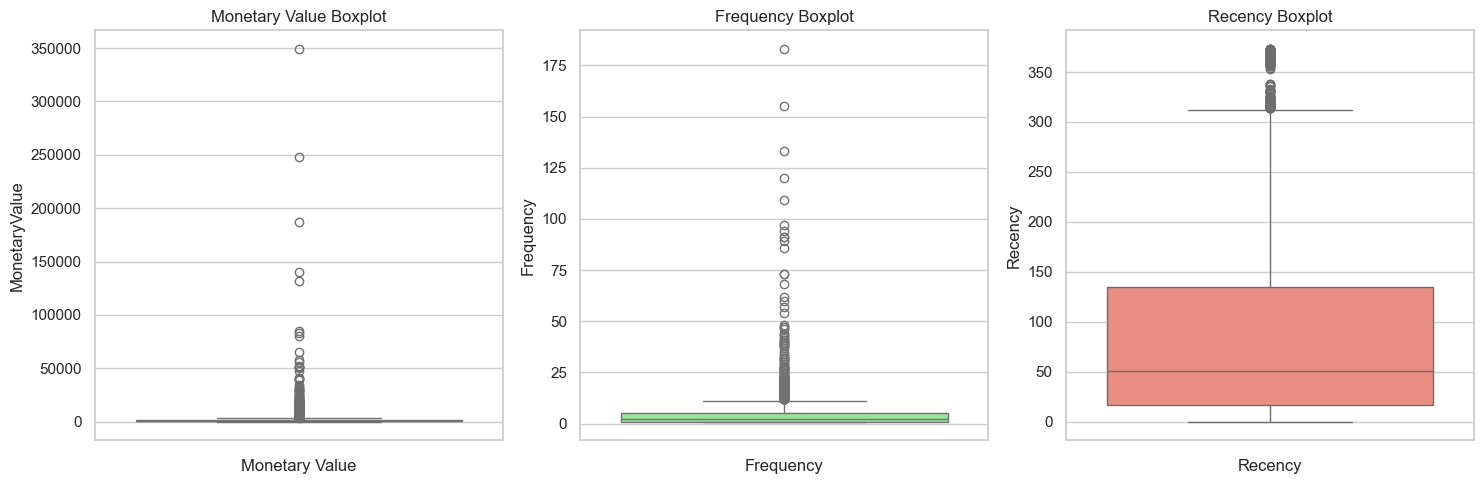

In [111]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

In [112]:
M_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1

monetary_outliers_df = aggregated_df[(aggregated_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR)) | (aggregated_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))].copy()

monetary_outliers_df.describe()


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,421.00,421.00,421.00,421,421.00
mean,15079.77,12198.21,17.16,2010-11-09 13:16:23.087886,30.00
min,12357.00,3788.21,1.00,2009-12-10 18:03:00,0.00
25%,13599.00,4590.53,8.00,2010-11-08 14:14:00,3.00
50%,14936.00,6171.07,12.00,2010-11-26 12:19:00,13.00
75%,16656.00,10300.98,18.00,2010-12-06 10:03:00,31.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,364.00
std,1723.92,25886.95,19.77,NaN,51.61


In [113]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1

frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) | (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()

frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,15352.66,14374.12,23.81,2010-11-23 11:06:20.645161,16.09
min,12437.00,1091.44,12.00,2010-05-12 16:51:00,0.00
25%,13800.00,4328.43,13.00,2010-11-20 13:14:30,2.00
50%,15465.00,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,16828.50,11652.41,23.00,2010-12-07 11:08:30,19.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,211.00
std,1748.43,31383.98,21.93,NaN,26.59


In [114]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers_df.index))]

non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3810.00,3810.00,3810.00,3810,3810.00
mean,15378.29,880.96,2.87,2010-09-03 11:26:19.795275,97.08
min,12346.00,1.55,1.00,2009-12-01 10:49:00,0.00
25%,13913.50,277.40,1.00,2010-07-08 15:37:30,22.00
50%,15390.50,581.12,2.00,2010-10-12 16:05:30,58.00
75%,16856.75,1256.62,4.00,2010-11-17 13:14:00,154.00
max,18287.00,3786.70,11.00,2010-12-09 20:01:00,373.00
std,1693.11,815.59,2.25,NaN,98.10


In [115]:
non_outliers_df.head(10)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10
5,12352.00,343.80,2,2010-11-29 10:07:00,10
6,12353.00,317.76,1,2010-10-27 12:44:00,43
7,12355.00,488.21,1,2010-05-21 11:59:00,202
8,12356.00,3124.30,3,2010-11-24 12:24:00,15
10,12358.00,2519.01,3,2010-11-29 10:56:00,10


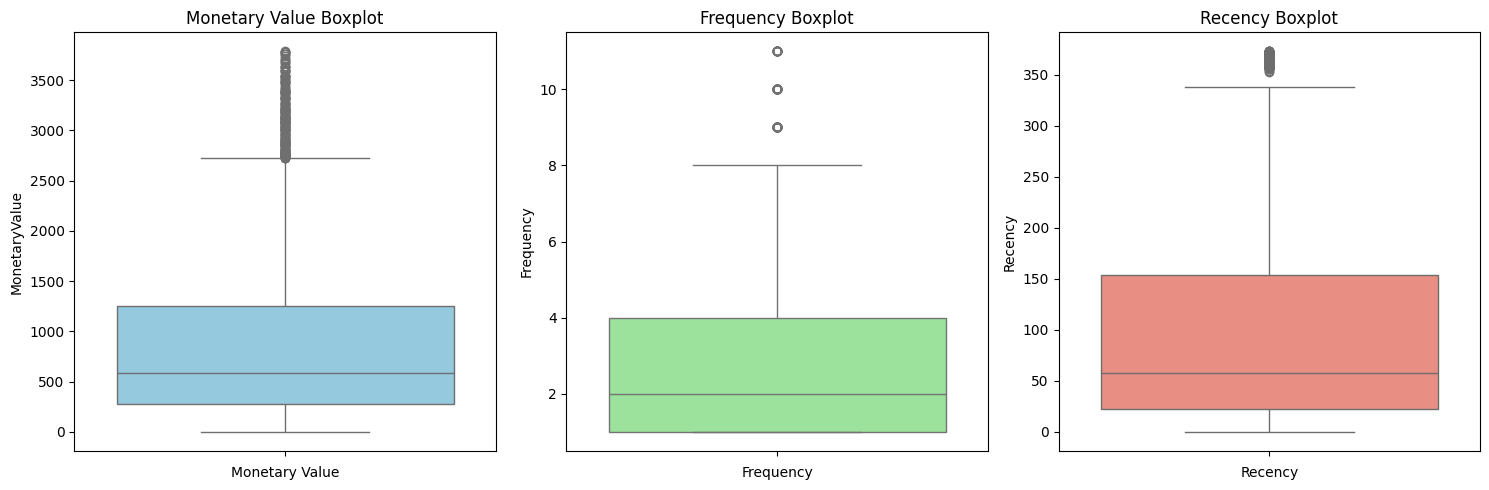

In [40]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

In [116]:
non_outliers_df["R_Score"] = pd.qcut(non_outliers_df["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
non_outliers_df["F_Score"] = pd.qcut(non_outliers_df["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
non_outliers_df["M_Score"] = pd.qcut(non_outliers_df["MonetaryValue"], 5, labels=[1,2,3,4,5]).astype(int)
non_outliers_df["RFM_Score"] = non_outliers_df["R_Score"].astype(str) + \
                               non_outliers_df["F_Score"].astype(str) + \
                               non_outliers_df["M_Score"].astype(str)
non_outliers_df.head(10)


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,R_Score,F_Score,M_Score,RFM_Score
0,12346.00,169.36,2,2010-06-28 13:53:00,164,2,2,1,221
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,5,2,4,524
2,12348.00,221.16,1,2010-09-27 14:59:00,73,3,1,1,311
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,4,2,5,425
4,12351.00,300.93,1,2010-11-29 15:23:00,10,5,1,2,512
5,12352.00,343.80,2,2010-11-29 10:07:00,10,5,2,2,522
6,12353.00,317.76,1,2010-10-27 12:44:00,43,3,1,2,312
7,12355.00,488.21,1,2010-05-21 11:59:00,202,1,1,3,113
8,12356.00,3124.30,3,2010-11-24 12:24:00,15,5,3,5,535
10,12358.00,2519.01,3,2010-11-29 10:56:00,10,5,3,5,535


In [121]:
def assign_rfm_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "VIP"
    elif row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Loyal"
    elif row["R_Score"] <= 2:
        return "At-Risk"
    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "New"
    elif row["M_Score"] <= 2 and row["F_Score"] <= 2:
        return "Low-Value"
    else:
        return "Others"



In [125]:
non_outliers_df["Segment"] = non_outliers_df.apply(assign_rfm_segment, axis=1)

print(non_outliers_df["Segment"].unique())

<ArrowStringArray>
['At-Risk', 'New', 'Low-Value', 'Loyal', 'Others', 'VIP']
Length: 6, dtype: str


In [127]:
non_outliers_df[["Customer ID", "RFM_Score", "Segment"]].head(10)



,Customer ID,RFM_Score,Segment
0,12346.00,221,At-Risk
1,12347.00,524,New
2,12348.00,311,Low-Value
3,12349.00,425,New
4,12351.00,512,New
5,12352.00,522,New
6,12353.00,312,Low-Value
7,12355.00,113,At-Risk
8,12356.00,535,Loyal
10,12358.00,535,Loyal


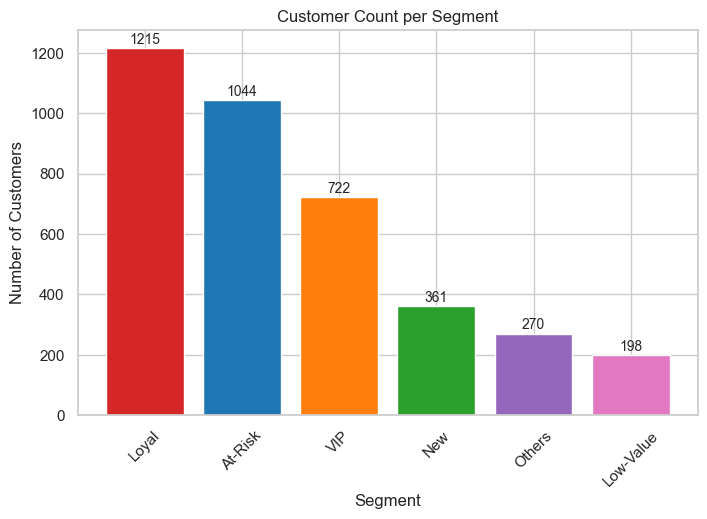

In [129]:
import matplotlib.pyplot as plt

# Count customers per segment
segment_counts = non_outliers_df["Segment"].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(segment_counts.index, segment_counts.values, 
               color=['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#e377c2'])

# Add exact count on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(int(height)), 
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Count per Segment")
plt.xticks(rotation=45)
plt.show()


In [130]:
non_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.00,169.36,2,2010-06-28 13:53:00,164,2,2,1,221,At-Risk
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,5,2,4,524,New
2,12348.00,221.16,1,2010-09-27 14:59:00,73,3,1,1,311,Low-Value
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,4,2,5,425,New
4,12351.00,300.93,1,2010-11-29 15:23:00,10,5,1,2,512,New
...,...,...,...,...,...,...,...,...,...,...
4280,18283.00,619.37,6,2010-11-22 15:30:00,17,5,5,3,553,Loyal
4281,18284.00,411.68,1,2010-10-04 11:33:00,66,3,2,2,322,Low-Value
4282,18285.00,377.00,1,2010-02-17 10:24:00,295,1,2,2,122,At-Risk
4283,18286.00,1246.43,2,2010-08-20 11:57:00,111,2,3,4,234,Loyal


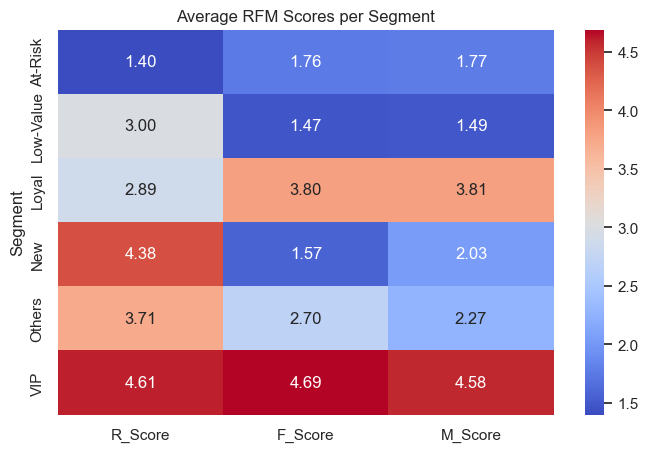

In [131]:
rfm_score_avg = non_outliers_df.groupby("Segment")[["R_Score", "F_Score", "M_Score"]].mean()

plt.figure(figsize=(8,5))
sns.heatmap(rfm_score_avg, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Average RFM Scores per Segment")
plt.show()



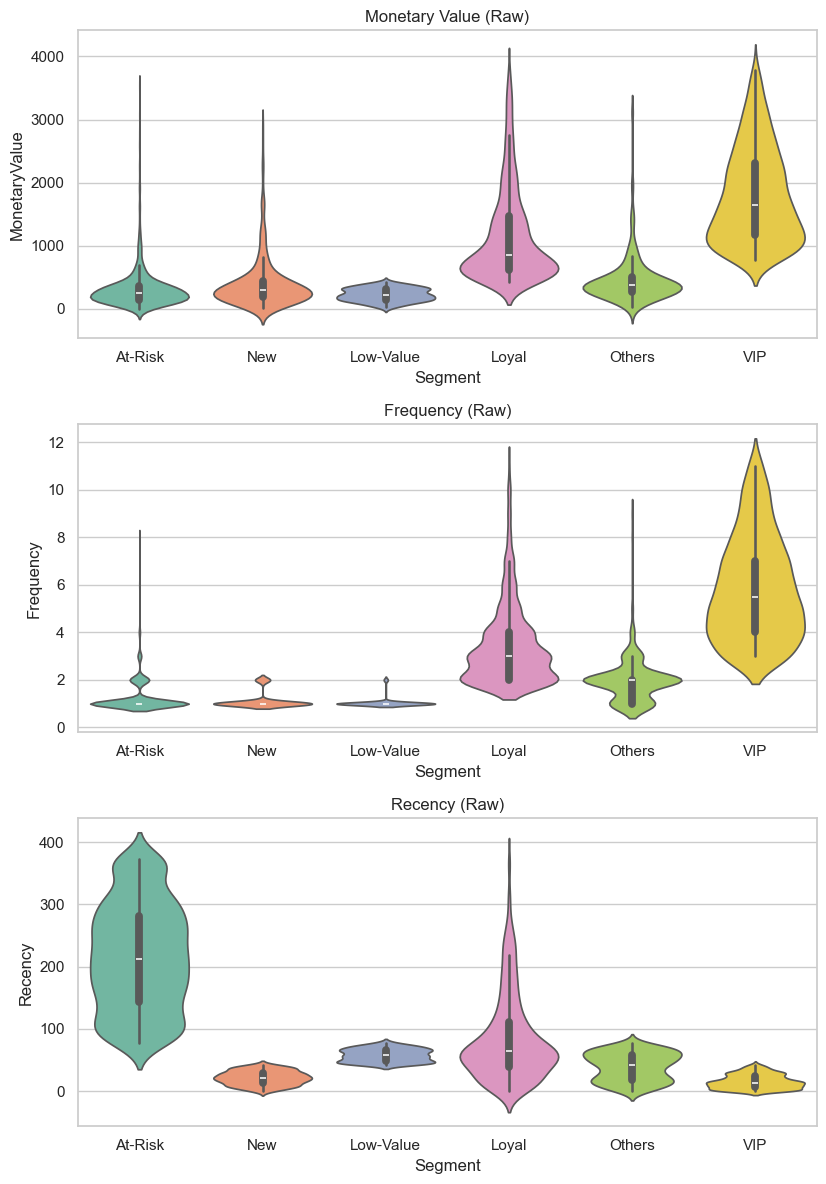

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure you have R, F, M scores already calculated
# Columns: 'R_Score', 'F_Score', 'M_Score'

plt.figure(figsize=(16, 12))

# ----- Monetary -----
plt.subplot(3, 2, 1)
sns.violinplot(x='Segment', y='MonetaryValue', data=non_outliers_df, palette='Set2')
plt.title('Monetary Value (Raw)')



# ----- Frequency -----
plt.subplot(3, 2, 3)
sns.violinplot(x='Segment', y='Frequency', data=non_outliers_df, palette='Set2')
plt.title('Frequency (Raw)')



# ----- Recency -----
plt.subplot(3, 2, 5)
sns.violinplot(x='Segment', y='Recency', data=non_outliers_df, palette='Set2')
plt.title('Recency (Raw)')



plt.tight_layout()
plt.show()


In [134]:
overlap_indices = monetary_outliers_df.index.intersection(
    frequency_outliers_df.index
)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_frequency_outliers = aggregated_df.loc[overlap_indices]


In [135]:
monetary_only_outliers["Segment"] = "High-Spend Elites"
frequency_only_outliers["Segment"] = "Ultra-Frequent Buyers"
monetary_frequency_outliers["Segment"] = "Platinum Customers"


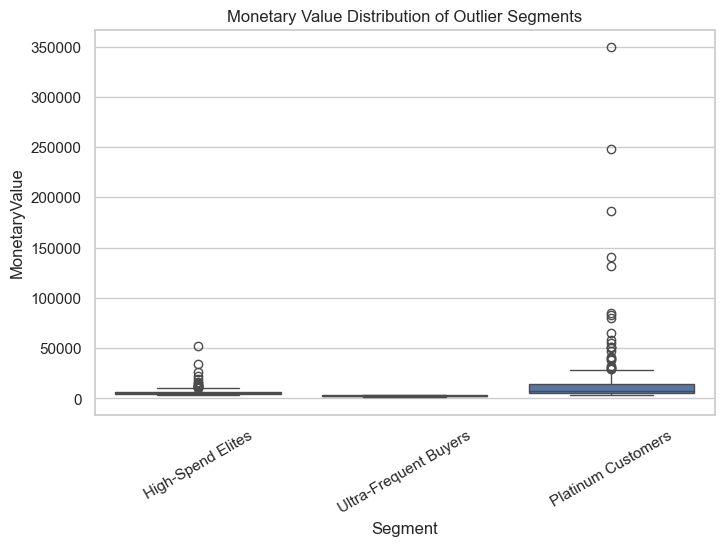

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Segment",
    y="MonetaryValue",
    data=outliers_df
)
plt.title("Monetary Value Distribution of Outlier Segments")
plt.xticks(rotation=30)
plt.show()


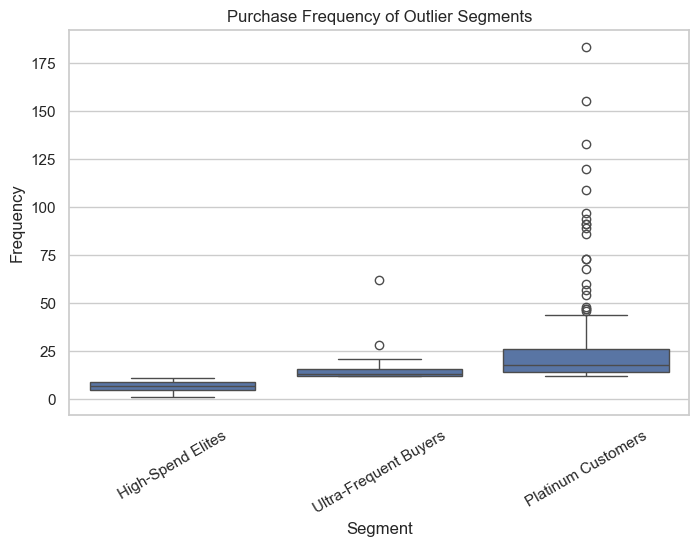

In [142]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Segment",
    y="Frequency",
    data=outliers_df
)
plt.title("Purchase Frequency of Outlier Segments")
plt.xticks(rotation=30)
plt.show()



In [136]:
outliers_df = pd.concat([
    monetary_only_outliers,
    frequency_only_outliers,
    monetary_frequency_outliers
])


In [137]:
outliers_df["Segment_Type"] = "Outlier"


In [138]:
non_outliers_df["Segment_Type"] = "Normal"



In [139]:
final_rfm_df = pd.concat([
    non_outliers_df,
    outliers_df
])


In [140]:
final_rfm_df["Segment"].value_counts()


Segment
Loyal                    1215
At-Risk                  1044
VIP                       722
New                       361
Others                    270
Platinum Customers        225
Low-Value                 198
High-Spend Elites         196
Ultra-Frequent Buyers      54
Name: count, dtype: int64

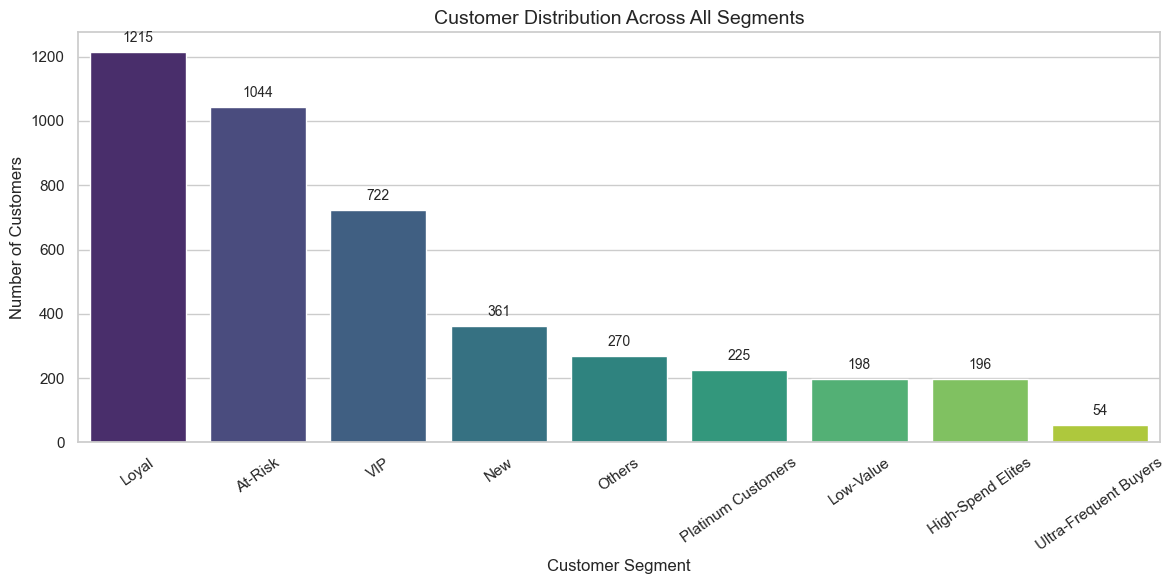

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count customers per segment
segment_counts = final_rfm_df["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Count"]

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x="Segment",
    y="Count",
    data=segment_counts,
    palette="viridis"
)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )

# Titles and labels
plt.title("Customer Distribution Across All Segments", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=35)
plt.tight_layout()

plt.show()


## Interpretation of Customer Segment Distribution

The bar chart illustrates the distribution of customers across all RFM-based segments, including non-outliers and outliers.

---

### Segment Sizes (from highest to lowest)

| Segment | Number of Customers | Interpretation |
|--------|---------------------|----------------|
| **Loyal** | 1215 | Core customer base with consistent purchasing behavior |
| **At-Risk** | 1044 | Large group with high churn risk |
| **VIP** | 722 | High-value customers with strong engagement |
| **New** | 361 | Recently acquired customers with growth potential |
| **Others** | 270 | Customers with mixed or transitional behavior |
| **Platinum Customers** | 225 | Extremely valuable customers with high spending and frequency |
| **Low-Value** | 198 | Price-sensitive customers with low contribution |
| **High-Spend Elites** | 196 | Customers who spend large amounts but purchase less frequently |
| **Ultra-Frequent Buyers** | 54 | Small but highly active customer group |

---

### Key Business Insights

- **Loyal customers** form the largest segment, indicating strong customer retention.
- The **At-Risk segment** is nearly as large as the Loyal group, highlighting a significant churn concern.
- **VIP and Platinum Customers**, although smaller in number, represent high revenue potential.
- **Outlier segments** (High-Spend Elites and Ultra-Frequent Buyers) consist of very few customers but exhibit exceptional purchasing behavior.
- The **Ultra-Frequent Buyers** segment is the smallest but shows intense engagement and repeat activity.

---

### Summary

While the majority of customers fall into regular behavioral segments, a small number of outlier customers contribute disproportionately to business value. These insights emphasize the need for differentiated marketing and retention strategies across customer segments.


## Segment Descriptions and Marketing Strategies

### Non-Outlier Customer Segments

| Segment | Description | Marketing Strategies | Objective |
|--------|------------|---------------------|-----------|
| **At-Risk** | Customers who have not purchased recently; low to medium frequency and monetary value; high churn probability | Win-back email campaigns, time-limited discounts, reminder notifications, reactivation coupons | Bring customers back before they churn |
| **New** | Very recent buyers with low purchase frequency; relationship still developing | Welcome email series, product education, first-time buyer offers, free shipping | Convert new customers into repeat buyers |
| **Low-Value** | Infrequent purchases, low spending behavior, limited engagement | Product bundling, cross-selling, price-sensitive offers, cost-effective campaigns | Increase purchase value at low cost |
| **Loyal** | Regular purchasing behavior; moderate to high spending; consistent engagement | Loyalty programs, reward points, personalized recommendations, early access to promotions | Maintain loyalty and grow customer value |
| **Others** | Mixed or transitional behavior; no clear segment fit | Behavioral analysis, A/B testing campaigns, observation-based targeting | Identify future potential or churn risk |
| **VIP** | Recent and frequent purchasers; high monetary contribution; most valuable regular customers | Exclusive offers, premium support, personalized communication, early product launches | Maximize retention and lifetime value |

---

### Outlier Customer Segments

| Segment | Description | Marketing Strategies | Business Insight |
|--------|------------|---------------------|------------------|
| **High-Spend Elites** | Extremely high spending; low to moderate purchase frequency; premium or bulk buyers | White-glove service, personalized pricing, dedicated account management, luxury positioning | Loss of one customer can significantly impact revenue |
| **Ultra-Frequent Buyers** | Extremely high purchase frequency; moderate spend per transaction; habit-driven behavior | Subscription models, auto-reorder options, loyalty tiers, gamified rewards | Generate consistent and predictable revenue |
| **Platinum Customers** | Very high spending and very high frequency; rare and extremely valuable | Invite-only programs, lifetime discounts, relationship management, surprise rewards | Represent the highest strategic value |

---

### Summary

Non-outlier segments reflect regular customer behavior, while outlier segments capture exceptional spending or purchasing patterns. Each segment requires tailored marketing and retention strategies to maximize customer lifetime value.
